# Aurora spectrum resolution and storage test

## tl;dr

Using the real cloudy `climate_01.npz` cache and its companion PICASO case, the production writer produced: **R=150: 588 points, 0.210 MiB/file, 0.238 TB for 1,080,000 files; R=1,500: 5,870 points, 1.232 MiB/file, 1.395 TB total; R=15,000: 58,682 points, 10.236 MiB/file, 11.592 TB total**. These totals are measured-file extrapolations for spectrum NetCDFs only.

## Context & Methods

The test deliberately reuses the production code path: `wavelength_grid_um` for constant-R sampling, `build_aurora_run_dataset` for the current schema, and `write_aurora_run_netcdf` for the compressed `.nc` file. One legacy Cahoy `.npz` climate cache is selected; its companion pickled converged PICASO case is loaded automatically by the repository cache loader. The reflected spectrum is calculated once, then the same native PICASO result is sampled onto each requested output grid exactly as the grid runner samples onto its configured output grid.

### Key Assumptions

- Wavelength limits are read from `aurora_subneptune_v1_dhuang.yaml` (0.3–15.0 µm).
- Total storage equals the measured size of one `.nc` multiplied by the YAML Cartesian-product spectrum count.
- This is a one-case estimate. Compression varies with atmospheric/cloud structure, so it is not a distributional capacity study.
- Extrapolated totals exclude climate caches, manifests, QC plots, logs, filesystem block overhead, replication, and backups.

In [1]:
from __future__ import annotations

import csv
import math
import os
import sys
import time
from functools import reduce
from operator import mul
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import yaml
from IPython.display import display

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() and (candidate / 'roadrunner_egp/aurora_subneptune_grid').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the Aurora repository root.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
GRID_ROOT = REPO_ROOT / 'roadrunner_egp/aurora_subneptune_grid'
GRID_SRC = GRID_ROOT / 'src'
ROADRUNNER_ROOT = REPO_ROOT / 'roadrunner_egp'
for path in (GRID_SRC, ROADRUNNER_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ['picaso_refdata'] = str(REPO_ROOT / 'picaso4_reference')
os.environ['PYSYN_CDBS'] = str(REPO_ROOT / 'picaso4_reference/stellar_grids')
os.environ['PICASO_CK_ROOT'] = str(REPO_ROOT / 'picaso4_reference/opacities')
os.environ['ROADRUNNER_PICASO_VIRGA_DIR'] = str(REPO_ROOT / 'picaso4_reference/virga/virga')
os.environ['ROADRUNNER_PICASO_VIRGA_CONDENSATES'] = 'MgSiO3,Mg2SiO4,Na2S,KCl,MnS,ZnS'
os.environ['ROADRUNNER_REQUIRE_VIRGA'] = '1'

from aurora_grid.cahoy_climate_cache import load_climate_cache
from aurora_grid.io.netcdf_schema import (
    build_aurora_run_dataset,
    validate_aurora_netcdf_schema,
    write_aurora_run_netcdf,
)
from aurora_grid.picaso_runner import (
    _reflected_observables,
    _system_from_row,
    run_picaso_model_from_climate_cache,
    wavelength_grid_um,
)
from roadrunner.runner import extract_planet_fluxes

print(f'Repository: {REPO_ROOT}')
print(f'Python: {sys.executable}')

Repository: /home/u11/danielxinhuang/Documents/aurora
Python: /home/u11/danielxinhuang/Documents/aurora/.venv-picaso4/bin/python


## Data

### 1. Read the production grid and select one cache

In [2]:
CONFIG_PATH = GRID_ROOT / 'params/aurora_subneptune_v1_dhuang.yaml'
MANIFEST_PATH = GRID_ROOT / 'manifests/aurora_cahoy2010_replication_v0_manifest.csv'
CACHE_PATH = GRID_ROOT / 'outputs/aurora_cahoy2010_replication_v0/climate_cache/climate_01.npz'
OUTPUT_DIR = GRID_ROOT / 'outputs/spectrum_resolution_storage_test'
RESOLUTIONS = (150, 1_500, 15_000)

with CONFIG_PATH.open() as handle:
    config = yaml.safe_load(handle)

axis_names = [
    'stars', 'planet_radius_rearth', 'planet_mass_mearth', 'metallicity_xsolar',
    'c_to_o_xsolar', 'kzz_cm2_s', 'cloud_fraction', 'fsed',
    'insolation_searth', 'phase_deg',
]
axis_lengths = {name: len(config[name]) for name in axis_names}
grid_spectrum_count = reduce(mul, axis_lengths.values(), 1)
wave_config = config['netcdf']['wavelength_grid']
wavelength_min_um = float(wave_config['min_um'])
wavelength_max_um = float(wave_config['max_um'])

with MANIFEST_PATH.open(newline='') as handle:
    manifest_rows = list(csv.DictReader(handle))
base_row = next(row for row in manifest_rows if int(row['climate_group_index']) == 1 and float(row['phase_deg']) == 0.0)

cache_size_bytes = CACHE_PATH.stat().st_size
case_path = CACHE_PATH.with_name(f'{CACHE_PATH.stem}_case.pkl')
source_summary = pd.DataFrame([{
    'selected_cache': str(CACHE_PATH.relative_to(REPO_ROOT)),
    'cache_size_KiB': cache_size_bytes / 1024,
    'companion_case': str(case_path.relative_to(REPO_ROOT)),
    'case_size_KiB': case_path.stat().st_size / 1024,
    'cloud_model': base_row['cloud_model'],
    'cloud_fraction': float(base_row['cloud_fraction']),
    'phase_deg': float(base_row['phase_deg']),
    'grid_spectra': grid_spectrum_count,
}])
display(source_summary.style.format({'cache_size_KiB': '{:,.2f}', 'case_size_KiB': '{:,.2f}', 'grid_spectra': '{:,}'}))
assert grid_spectrum_count == 1_080_000
assert CACHE_PATH.exists() and case_path.exists()

,selected_cache,cache_size_KiB,companion_case,case_size_KiB,cloud_model,cloud_fraction,phase_deg,grid_spectra
0,roadrunner_egp/aurora_subneptune_grid/outputs/aurora_cahoy2010_replication_v0/climate_cache/climate_01.npz,16.57,roadrunner_egp/aurora_subneptune_grid/outputs/aurora_cahoy2010_replication_v0/climate_cache/climate_01_case.pkl,522.01,virga,1.000000,0.000000,"1,080,000"


### 2. Load the real converged PICASO state

In [3]:
load_started = time.perf_counter()
climate_cache = load_climate_cache(CACHE_PATH)
cache_load_seconds = time.perf_counter() - load_started

cache_profile = pd.DataFrame({
    'pressure_bar': climate_cache['pressure'],
    'temperature_K': climate_cache['temperature'],
})
print(f'Loaded cache + companion {type(climate_cache.get("cl_run")).__name__} in {cache_load_seconds:.2f} s')
display(cache_profile.iloc[[0, 1, -2, -1]].reset_index(names='level'))

Loaded cache + companion inputs in 0.01 s


,level,pressure_bar,temperature_K
0,0,0.000001,198.868848
1,1,0.000001,197.295763
2,59,23.713737,565.410815
3,60,31.622777,616.007302


## Results

### 3. Run one real reflected spectrum at the maximum requested R

PICASO's correlated-k spectrum is calculated once over the production wavelength range. The native result is then sampled to each requested constant-R output grid, matching the repository's output-grid behavior.

In [4]:
production_row = dict(base_row)
production_row.update({
    'wavelength_grid_mode': 'constant_resolution',
    'wavelength_min_um': wavelength_min_um,
    'wavelength_max_um': wavelength_max_um,
    'wavelength_resolution': max(RESOLUTIONS),
    'model_name': 'spectrum_resolution_storage_test',
    'run_id': 'storage-test-native',
    'notes': 'Single real PICASO cached-climate run for Aurora NetCDF storage sizing.',
})

spectrum_started = time.perf_counter()
native_model_output = run_picaso_model_from_climate_cache(production_row, climate_cache)
spectrum_runtime_seconds = time.perf_counter() - spectrum_started
native_wavelength_points = np.asarray(native_model_output['picaso_out_reflected']['wavenumber']).size
print(f'PICASO spectrum completed in {spectrum_runtime_seconds:.2f} s')
print(f'Native PICASO points: {native_wavelength_points:,}')
print(f'R=15,000 output points: {len(native_model_output["wavelength_um"]):,}')

PICASO spectrum completed in 2.71 s
Native PICASO points: 196
R=15,000 output points: 58,682


### 4. Write all three files through the Aurora NetCDF framework

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
system = _system_from_row(production_row)
out_reflected = native_model_output['picaso_out_reflected']
results = []

for resolution in RESOLUTIONS:
    row = dict(production_row)
    row['wavelength_resolution'] = resolution
    row['run_index'] = resolution
    row['run_id'] = f'storage-test-R{resolution}'
    output_path = OUTPUT_DIR / f'aurora_spectrum_R{resolution}.nc'
    row['output_nc'] = str(output_path.relative_to(REPO_ROOT))

    output_grid = wavelength_grid_um(row)
    albedo, fpfs_reflection = _reflected_observables(out_reflected, system, output_grid)
    _, absolute_flux_reflected, absolute_flux_thermal = extract_planet_fluxes(
        out_reflected, {}, output_grid, system
    )
    model_output = dict(native_model_output)
    model_output.update({
        'wavelength_um': output_grid,
        'fpfs_reflection': fpfs_reflection,
        'albedo': albedo,
        'absolute_flux_reflected': absolute_flux_reflected,
        'absolute_flux_thermal': absolute_flux_thermal,
    })

    write_started = time.perf_counter()
    dataset = build_aurora_run_dataset(
        model_output, row, runtime_seconds=spectrum_runtime_seconds, run_success=True
    )
    in_memory_bytes = int(sum(variable.nbytes for variable in dataset.variables.values()))
    schema_issues_before_write = validate_aurora_netcdf_schema(dataset)
    write_status = write_aurora_run_netcdf(dataset, output_path, overwrite=True)
    write_seconds = time.perf_counter() - write_started

    with xr.open_dataset(output_path) as reopened:
        schema_issues_after_write = validate_aurora_netcdf_schema(reopened)
        stored_points = int(reopened.sizes['wavelength'])
        stored_min = float(reopened['wavelength_um'].min())
        stored_max = float(reopened['wavelength_um'].max())
        schema_name = reopened.attrs.get('schema_name')

    file_size_bytes = output_path.stat().st_size
    results.append({
        'R': resolution,
        'wavelength_points': stored_points,
        'expected_points': math.ceil(math.log(wavelength_max_um / wavelength_min_um) * resolution) + 1,
        'min_um': stored_min,
        'max_um': stored_max,
        'file_size_bytes': file_size_bytes,
        'file_size_MiB': file_size_bytes / 2**20,
        'in_memory_MiB': in_memory_bytes / 2**20,
        'compression_ratio': in_memory_bytes / file_size_bytes,
        'write_seconds': write_seconds,
        'grid_total_bytes': file_size_bytes * grid_spectrum_count,
        'grid_total_TB': file_size_bytes * grid_spectrum_count / 10**12,
        'grid_total_TiB': file_size_bytes * grid_spectrum_count / 2**40,
        'output_file': str(output_path.relative_to(REPO_ROOT)),
        'engine': write_status['netcdf_engine'],
        'schema_name': schema_name,
        'schema_errors': len([x for x in schema_issues_before_write + schema_issues_after_write if x.startswith('ERROR:')]),
    })

results_df = pd.DataFrame(results).sort_values('R').reset_index(drop=True)
assert (results_df['wavelength_points'] == results_df['expected_points']).all()
assert (results_df['schema_name'] == 'aurora_subneptune_netcdf').all()
assert (results_df['schema_errors'] == 0).all()
display(results_df[[
    'R', 'wavelength_points', 'file_size_bytes', 'file_size_MiB',
    'grid_total_TB', 'grid_total_TiB', 'write_seconds', 'engine', 'schema_errors'
]].style.format({
    'R': '{:,}', 'wavelength_points': '{:,}', 'file_size_bytes': '{:,}',
    'file_size_MiB': '{:,.3f}', 'grid_total_TB': '{:,.3f}',
    'grid_total_TiB': '{:,.3f}', 'write_seconds': '{:,.2f}',
}))

,R,wavelength_points,file_size_bytes,file_size_MiB,grid_total_TB,grid_total_TiB,write_seconds,engine,schema_errors
0,150,588,"220,406",0.210,0.238,0.216,0.26,netcdf4,0
1,"1,500","5,870","1,291,623",1.232,1.395,1.269,0.33,netcdf4,0
2,"15,000","58,682","10,733,582",10.236,11.592,10.543,1.32,netcdf4,0


### 5. Compare the spectra and storage scaling

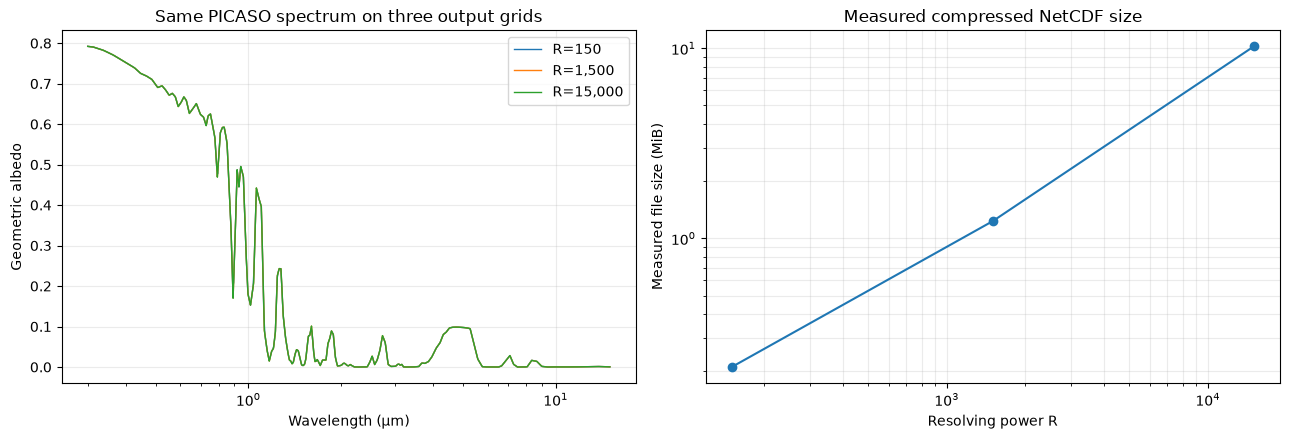

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for resolution in RESOLUTIONS:
    path = OUTPUT_DIR / f'aurora_spectrum_R{resolution}.nc'
    with xr.open_dataset(path) as ds:
        axes[0].plot(ds['wavelength_um'], ds['geometric_albedo'], label=f'R={resolution:,}', linewidth=1.0)
axes[0].set(xlabel='Wavelength (µm)', ylabel='Geometric albedo', xscale='log', title='Same PICASO spectrum on three output grids')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(results_df['R'], results_df['file_size_MiB'], marker='o', label='One NetCDF')
axes[1].set(xlabel='Resolving power R', ylabel='Measured file size (MiB)', xscale='log', yscale='log', title='Measured compressed NetCDF size')
axes[1].grid(alpha=0.25, which='both')
plt.tight_layout()
plt.show()

### 6. Independent calculation checks

In [7]:
check_rows = []
for result in results:
    path = REPO_ROOT / result['output_file']
    independent_size = os.path.getsize(path)
    independent_total = independent_size * grid_spectrum_count
    check_rows.append({
        'R': result['R'],
        'size_matches': independent_size == result['file_size_bytes'],
        'point_formula_matches': result['wavelength_points'] == result['expected_points'],
        'total_matches': independent_total == result['grid_total_bytes'],
        'schema_errors': result['schema_errors'],
    })
checks_df = pd.DataFrame(check_rows)
display(checks_df)
assert checks_df[['size_matches', 'point_formula_matches', 'total_matches']].all().all()
assert (checks_df['schema_errors'] == 0).all()

,R,size_matches,point_formula_matches,total_matches,schema_errors
0,150,True,True,True,0
1,1500,True,True,True,0
2,15000,True,True,True,0


## Takeaways

For the current YAML setting of **R=15,000**, this test projects **11.592 TB (10.543 TiB)** for 1,080,000 spectrum NetCDFs. Reducing to R=1,500 projects **1.395 TB**, and R=150 projects **0.238 TB**. File size does not scale perfectly linearly with R because every file has fixed schema/profile content and HDF5 compression. Add operational headroom for 180,000 climate caches, QC products, filesystem allocation, replication, and backups. This single cloudy case is reproducible but is not a worst-case bound; sample several clear, cloudy, and partially cloudy production cases before reserving final capacity.